
CROSS VALIDATION SCORES:
fit_time: 11.686
score_time: 0.645
test_roc_auc: 0.877
test_f1: 0.709
test_recall: 0.646

Best Threshold: 0.36

FINAL METRICS
Accuracy: 0.8250961538461539
Precision: 0.7028218694885362
Recall: 0.7474210690840888
F1: 0.7244356915618846
ROC-AUC: 0.8769554773812935
PR-AUC: 0.7754678194173082


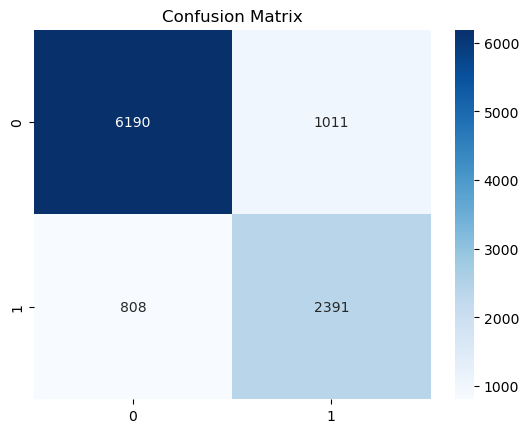

In [ ]:
# =========================================
# STUDENT DROPOUT FULL PIPELINE (CORRECTED)
# =========================================
import sys
!{sys.executable} -m pip install shap

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

import matplotlib.pyplot as plt
import seaborn as sns
import shap

# =========================
# LOAD DATA
# =========================

df = pd.read_csv("C:/Users/hp/Downloads/student_dropout_dataset.csv")

# =========================
# CLEAN + PREPROCESS
# =========================

df_model = df.copy()

# DROP leakage columns 
df_model = df_model.drop(["student_id", "risk_score", "risk_level"], axis=1, errors="ignore")

# ENCODE
df_model["class_participation"] = df_model["class_participation"].map({
    "Low": 0, "Medium": 1, "High": 2
})

df_model["background"] = (df_model["background"] == "Urban").astype(int)

# =========================
# FEATURE ENGINEERING
# =========================

df_model["academic_score"] = (
    0.40 * df_model["marks_avg"] +
    0.35 * df_model["test_score"] +
    0.25 * df_model["assignment_completion"]
)

df_model["engagement_score"] = (
    (df_model["attendance"] * 0.40) +
    (df_model["login_frequency"] / 30 * 0.35 * 100) +
    (df_model["study_hours_per_week"] / 40 * 0.25 * 100)
)

df_model["low_attendance_flag"] = (df_model["attendance"] < 50).astype(int)
df_model["low_marks_flag"] = (df_model["marks_avg"] < 40).astype(int)

df_model["double_risk_flag"] = (
    (df_model["low_attendance_flag"] == 1) &
    (df_model["low_marks_flag"] == 1)
).astype(int)

# =========================
# SPLIT
# =========================

X = df_model.drop("dropout", axis=1)
y = df_model["dropout"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

# =========================
# MODEL
# =========================

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

# =========================
# CROSS VALIDATION
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=["roc_auc", "f1", "recall"]
)

print("\nCROSS VALIDATION SCORES:")
for k, v in cv_scores.items():
    print(f"{k}: {v.mean():.3f}")

# =========================
# TRAIN FINAL MODEL
# =========================

model.fit(X_train, y_train)

# =========================
# THRESHOLD TUNING
# =========================

val_probs = model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

best_threshold = thresholds[np.argmax(f1[:-1])]
print("\nBest Threshold:", round(best_threshold, 3))

# =========================
# FINAL TEST EVALUATION
# =========================

test_probs = model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print("\nFINAL METRICS")
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds))
print("Recall:", recall_score(y_test, test_preds))
print("F1:", f1_score(y_test, test_preds))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("PR-AUC:", average_precision_score(y_test, test_probs))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# =========================
# SHAP
# =========================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("\nSHAP Summary Plot")
shap.summary_plot(shap_values, X_test)

# =========================
# FEATURE IMPORTANCE
# =========================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# =========================
# RISK FUNCTIONS
# =========================

def get_risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.5:
        return "Medium"
    elif p < 0.7:
        return "Medium-High"
    else:
        return "High"

def get_action(level):
    if level == "Low":
        return "Monitor"
    elif level == "Medium":
        return "Send LMS alert"
    elif level == "Medium-High":
        return "Advisor call"
    else:
        return "Urgent counsellor action"

# =========================
# DASHBOARD DATA
# =========================

full_probs = model.predict_proba(X)[:, 1]
full_preds = (full_probs >= best_threshold).astype(int)

dashboard_df = df.copy()

dashboard_df["dropout_probability"] = full_probs
dashboard_df["predicted_dropout"] = full_preds
dashboard_df["risk_level"] = [get_risk_level(p) for p in full_probs]
dashboard_df["action"] = [get_action(r) for r in dashboard_df["risk_level"]]

# =========================
# SAVE FILES
# =========================

dashboard_df.to_csv("dashboard_data.csv", index=False)
importance_df.to_csv("feature_importance.csv", index=False)

# AGGREGATED DATA
risk_summary = dashboard_df["risk_level"].value_counts().reset_index()
risk_summary.columns = ["risk_level", "count"]
risk_summary.to_csv("risk_summary.csv", index=False)

dropout_by_participation = pd.crosstab(
    dashboard_df["class_participation"],
    dashboard_df["dropout"],
    normalize="index"
).reset_index()

dropout_by_participation.to_csv("dropout_by_participation.csv", index=False)

print("\nFILES GENERATED:")
print("dashboard_data.csv")
print("feature_importance.csv")
print("risk_summary.csv")
print("dropout_by_participation.csv")